<a href="https://colab.research.google.com/github/ankxie/PHYS633/blob/main/Book/L03-HydroStaticEQ/03-HydroStaticEQ-template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='purple'>Notebook 03-HydroStaticEQ</font>

> TODO: Angelina Tjia

## 0. We start by importing the modules
* Numpy -- operations on arrays and matrixes (and pi)
* Matplotlib pyplot -- plotting library
* Astropy units -- defined quantities with units. We also import the CDS conversions

In [1]:
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
# This option enables plots to be inline,
# as opposed to opening in a separate window.

from astropy import constants as const
import astropy.units as u
from astropy.units import cds
cds.enable()

## 1. Solving the equation of hydrostatic equilibium with known density.

### a. In class: the constant density case

For a density that is constant inside of the star, we found that

$\frac{P(r)}{P_o} = \left[ 1 - \left(\frac{r}{R_\star}\right)^2\right],$

where $P_o$ is the pressure at the center ($r=0$)

We will add this curve to the graph of $P(r)/P_c$ versus $r/R_\star$ below.


### b. At home: the decreasing density case

Now let's consider a density that varies as

$\rho = \rho_o\left(1-\frac{r}{R_\star}\right),$

as we did for the previous Notebook L02.

follow the same procedure to find $\frac{P(r)}{P_o}$, and add it to the plot below.

> **TODO** : follow the same procedure to find $\frac{P(r)}{P_o}$ for the decreasing density case. Write your solution below. This means starting from the HS differential equation, but you can use results from notebook L02 for $g(r)/g_\star$. Transform your integral to a unitless-form before performing the integration. Use Latex formatting to render the math

$$M_r(r)/M_\star = 12(\frac{x^3}{3} -  \frac{x^4}{4})$$

$$g(r)/g_\star = 12(\frac{x}{3} -  \frac{x^2}{4})$$

$$\frac{dP(r)}{dr} = -\rho(r)g(r)$$

$$P(r) - 0 = \int_{R_*}^{r' = r} - \rho_0 (1-x)g_*(4x - 3x^2)dr'$$

$$P(x) = - \rho_0 g_* R_* \int_{x' = 1}^{x' = x} (1-x)(4x - 3x^2)dx'$$

$$P(x) = \frac{-\rho_0 g_* R_*}{12}(-1 + x)^2 (-5 - 10 x + 9 x^2) $$

$$P(0) = \frac{5\rho_0 g_* R_*}{12}$$

$$\frac{P(x)}{P_0} = \frac{-1}{5}(-1 + x)^2 (-5 - 10 x + 9 x^2)$$

> **TODO** : Add this curve to the graph below, with a label in the legend.

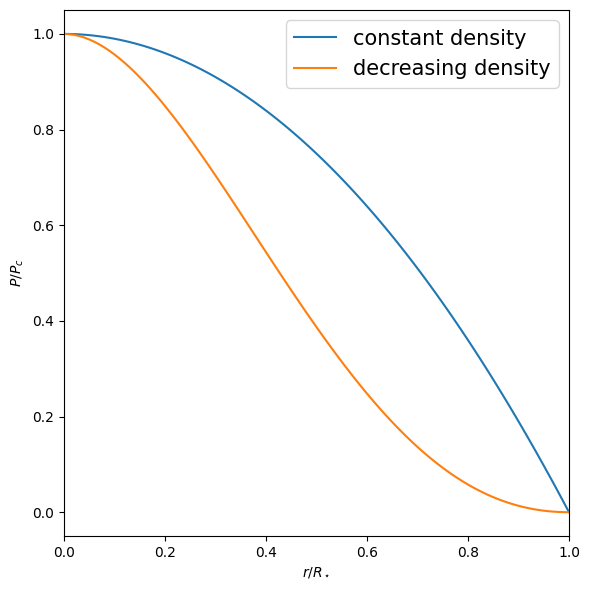

In [7]:
fig, ax = plt.subplots(1,1, figsize=(6,6))
# The subplot routine creates a figure object (in the variable "fig"), which contains
# here a single plotting window called "axes" (in the variable "ax")

ax.set_xlabel(r'$r/R_\star$') # the "r" is to say there is latex formatted strings.
ax.set_xlim(0,1)

ax.set_ylabel(r'$P/P_c$')

#-------------------------------------------------------
# In class

# define an array of r / Rs, from 0 to 1, with 100 elements
x_array = np.linspace(0, 1, 100)

# For constant density

ax.plot(x_array, np.ones_like(x_array) - x_array**2, label = 'constant density') #pressure with constant density


#-------------------------------------------------------
# For linearly decreasing density (portfolio)
# At home

scaled_p = -0.2 * (-1 + x_array)**2 * (-5 - 10*x_array + 9*x_array**2)

ax.plot(x_array, scaled_p, label = 'decreasing density')

#-------------------------------------------------------
ax.legend(loc=0, fontsize=15)
plt.tight_layout()
# arrange the plot nicely

> **TODO**: Please write a small paragraph with an interpretation of the result obtained:



## 2. Now we would like to calculate the numerical value of the central pressure for a star of $1M_\odot$ and $1R_\odot$.

To give an idea, the values of density and pressure at the center of the Sun from sophisticated models are 165 g/cm $^3$ and $2.5\times10^{17} \mathrm{dyn / cm}^2$, respectively.

### a. In class: the constant density case

We know that

$$M_\star = \frac{4\pi R_\star^3}{3} \rho_o.$$

Therefore the density is

$$\rho_o = M_\star \frac{3}{4\pi R_\star^3}.$$

The central pressure is

$$\frac{1}{2} \rho_o g_\star R_\star,$$

where the surface acceleration $g_\star = GM_\star / R_\star^2$.

In [17]:
############
# In class
############

# Let's start with a demo on how to use the unit capabilities of astropy

#print(u.Msun)
#print(1.0 * u.Msun)

rho = (1*u.Msun)/ (4* np.pi * (1*u.Rsun)**3 / 3)
#print(rho)
#print(rho.to(u.gram/u.cm**3))
#print(rho.cgs)

G = const.G.decompose()
Msun = const.M_sun.decompose()
Rsun = const.R_sun.decompose()
P = 0.5 * rho * G * Msun / Rsun
#print(P.to(u.dyn/u.cm**2))

print('For constant density, the density is {0:0.3g}'.format(rho.cgs))
print('For constant density, the central pressure is {0:0.3g}'.format(P.to(u.dyn/u.cm**2)))

For constant density, the density is 1.41 g / cm3
For constant density, the central pressure is 1.34e+15 dyn / cm2


> **TODO**: Please write a small paragraph with an interpretation of the result obtained:

A constant density model of a solar mass star would not have the same density or central pressure as our Sun. The constant density star would have a density and central pressure that are 2 orders of magnitude less than the Sun. This suggests that the Sun does not have constant density.

### b. At home: the linearly decreasing density case

> **TODO**: Now, you will derive expressions for the central density and central pressure (following the procedure above) for the case where we take the density to be $\rho = \rho_c\left(1-\frac{r}{R_\star}\right)$. Write your solution below in latex to render the math. You can refer to results (scaled equations) from your previous notebooks.

$$M_* = \frac{\pi R_*^3\rho_c}{3}$$

$$\rho_c = M_* (\frac{3}{\pi R_*^3})$$

$$P_c = \frac{5\rho_0 g_* R_*}{12}$$

> **TODO**: In the code cell below, use the astropy constant and unit packages to calculate the numerical values of the central density and central pressure for the decreasing density case. Make sure that the units are in the cgs pressure units, and that your 'print' statements include a label in front of the value.

In [19]:
#################
# At home
#################

rho = Msun * 3 /np.pi / Rsun**3
P = 5 * rho * G * Msun / 12 / Rsun

print('For decreasing density, the central density is {0:0.3g}'.format(rho.cgs))
print('For decreasing density, the central pressure is {0:0.3g}'.format(P.to(u.dyn/u.cm**2)))


For decreasing density, the density is 5.64 g / cm3
For decreasing density, the central pressure is 4.48e+15 dyn / cm2


> **TODO**: Please write a small paragraph with an interpretation of the result obtained:

This decreasing density model has a central density and pressure that is closer to the values for the Sun compared to the constant density model. It is probably closer to the actual density distribution within the Sun, but it is still not quite right. The Sun's density likely decreases more sharply.  

## 3. Reading assignement: "what can we measure about stars" -- part 2

In this graduate course, we are making an advanced physical and mathematical model of star.

But it is still good to learn and/or remind ourselves about which physical characteristics of stars we can actually measure. You might have covered some of this in some details in previous physics or astro courses (at UD PHYS 133, 144, 333, or 469) -- but it is still a good idea to have a quick look at the suggested reading below before crafting your paragraph.

One other thing that can be measured is the **distance** to a star.

> **TODO**: Have a look at section 19.2 "Celestial Distances > Surveying the Stars" of the Open Stack Astronomy online [textbook](https://openstax.org/books/astronomy/pages/5-2-the-electromagnetic-spectrum), and write a short conceptual paragraph about how astronomer can determine the distance to (nearby) stars.
You might also find is interesting to have a quick look at the GAIA space mission: https://sci.esa.int/web/gaia/-/28820-summary